In [1]:
# Cell 1 — imports
import re
import numpy as np
import matplotlib.pyplot as plt

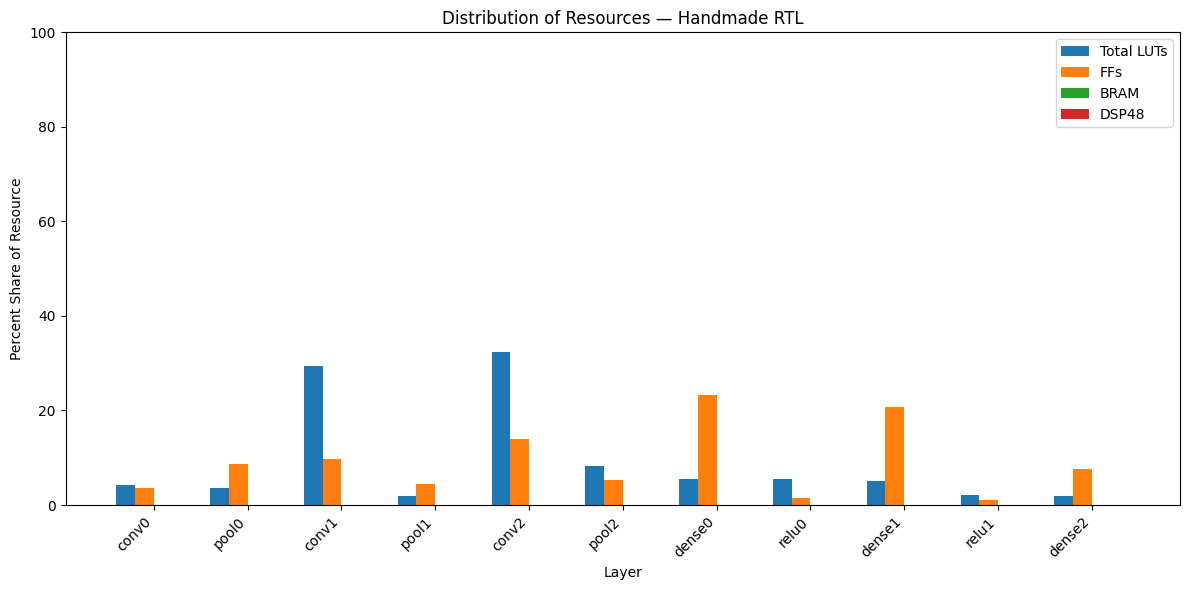

In [ ]:
def parse_hier_report(path):
    """
    Parses a Vivado 'report_utilization -hierarchical' .rpt file into a list of
    per-instance resource dicts. The report is an ASCII table where every real
    data row starts with '|'; we scan past the header to find the column-title
    row, then read rows until the closing table border.
    """
    with open(path) as f:
        lines = f.readlines()

    # Find the header row (the one containing both 'Instance' and 'Module' column titles)
    header_idx = next(i for i, l in enumerate(lines) if 'Instance' in l and 'Module' in l)

    rows = []
    # Data starts 2 lines after the header (header row + separator line)
    for line in lines[header_idx + 2:]:
        line = line.rstrip('\n')
        if not line.strip().startswith('|'):
            break  # hit the closing table border -- table is done

        # Split the row on '|' to get each column's raw text, trimming whitespace
        parts = [p.strip() for p in line.strip().strip('|').split('|')]
        if len(parts) < 11:
            continue  # malformed/short row, skip

        try:
            rows.append({
                'instance': parts[0],           # instance name (e.g. 'conv0')
                'total_luts': int(parts[2]),    # Total LUTs column
                'ffs': int(parts[6]),           # FFs column
                'bram': int(parts[7]) + int(parts[8]),  # RAMB36 + RAMB18 combined
                'dsp48': int(parts[10]),        # DSP48 Blocks column
            })
        except ValueError:
            continue  # non-numeric row (e.g. a stray separator), skip
    return rows


handmade_rows = parse_hier_report(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt"
)


# Map each logical layer name to the instance-name prefix(es) that belong to it --
# e.g. pool0 is split into two cascaded MaxPool stages (pool0Stage1 + pool0Stage2)
# across 6 parallel channel instances each, so both prefixes need to be captured.
handmade_groups = {
    'conv0': ['conv0'], 'pool0': ['pool0Stage1[', 'pool0Stage2['],
    'conv1': ['conv1'], 'pool1': ['pool1['],
    'conv2': ['conv2'], 'pool2': ['pool2['],
    'dense0': ['dense0'], 'relu0': ['relu0'],
    'dense1': ['dense1'], 'relu1': ['relu1'],
    'dense2': ['dense2'],
}

def aggregate(rows, groups):
    """
    Collapses many per-instance rows (e.g. 6 parallel MaxPool channel instances)
    into one summed total per logical layer name, based on instance-name prefix match.
    """
    out = {}
    for name, prefixes in groups.items():
        matched = [r for r in rows if any(r['instance'].startswith(p) for p in prefixes)]
        out[name] = {
            'total_luts': sum(r['total_luts'] for r in matched),
            'ffs': sum(r['ffs'] for r in matched),
            'bram': sum(r['bram'] for r in matched),
            'dsp48': sum(r['dsp48'] for r in matched),
        }
    return out

handmade_data = aggregate(handmade_rows, handmade_groups)


def plot_distribution(data, title):
    """
    Grouped bar chart: for each layer, shows what % of the DESIGN-WIDE total of
    each resource type that layer consumes (bars sum to ~100% per resource
    across all layers, not per layer).
    """
    layers = list(data.keys())
    metrics = ['total_luts', 'ffs', 'bram', 'dsp48']
    labels = ['Total LUTs', 'FFs', 'BRAM', 'DSP48']

    # Design-wide total per resource type, used as the denominator for % share
    totals = {m: sum(data[l][m] for l in layers) for m in metrics}

    values = []
    for l in layers:
        values.append([100 * data[l][m] / totals[m] if totals[m] > 0 else 0 for m in metrics])

    n_bars = len(metrics)
    x = np.arange(len(layers))
    bar_width = 0.8 / n_bars
    plt.figure(figsize=(12, 6))
    for i in range(n_bars):
        plt.bar(x + i * bar_width, [v[i] for v in values], width=bar_width, label=labels[i])
    plt.xticks(x + bar_width * (n_bars - 1) / 2, layers, rotation=45, ha='right')
    plt.ylabel('Percent Share of Resource')
    plt.xlabel('Layer')
    plt.ylim((0, 100))
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_distribution(handmade_data, 'Distribution of Resources — Handmade RTL')

Uncategorized instances: 4 (check these aren't significant)


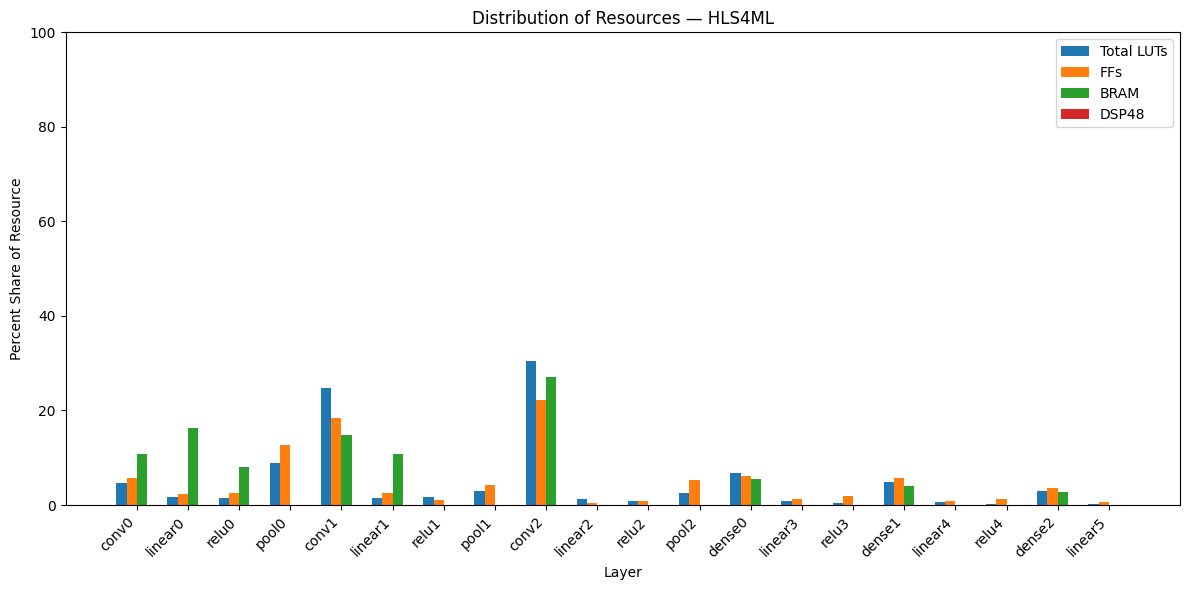

In [ ]:
hls4ml_rows = parse_hier_report(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt"
)

# hls4ml auto-generates instance names (e.g. 'conv_2d_cl_..._config2_U0') rather than
# human-readable ones. Each name embeds a numeric config/layer ID that corresponds
# 1:1 to a stage in the Keras model graph -- this maps those IDs to friendly names,
# built by matching each config number to its role while reading through the .rpt file.
config_to_name = {
    2: 'conv0', 3: 'linear0', 4: 'relu0', 5: 'pool0',
    6: 'conv1', 7: 'linear1', 8: 'relu1', 9: 'pool1',
    10: 'conv2', 11: 'linear2', 12: 'relu2', 13: 'pool2',
    15: 'dense0', 16: 'linear3', 17: 'relu3',
    18: 'dense1', 19: 'linear4', 20: 'relu4',
    21: 'dense2', 22: 'linear5',
}

def classify(instance):
    """
    Extracts the numeric config/layer ID from an hls4ml instance name and
    looks up its friendly layer name. Two naming patterns appear in the report:
    '..._config<N>_...' for compute modules, and 'layer<N>_out_...' for the
    FIFOs that buffer data between pipeline stages.
    """
    m = re.search(r'config(\d+)(?:[^0-9]|$)', instance)
    if m:
        return config_to_name.get(int(m.group(1)))
    m = re.search(r'^layer(\d+)_out', instance)
    if m:
        return config_to_name.get(int(m.group(1)))
    return None  # doesn't match either pattern (e.g. top-level wrapper row)

hls4ml_data = {name: {'total_luts': 0, 'ffs': 0, 'bram': 0, 'dsp48': 0} for name in set(config_to_name.values())}
uncategorized = 0
for r in hls4ml_rows:
    if r['instance'] in ('myproject', '(myproject)'):
        continue  # skip the top-level design-total row, not a real layer
    group = classify(r['instance'])
    if group is None:
        uncategorized += 1
        continue
    hls4ml_data[group]['total_luts'] += r['total_luts']
    hls4ml_data[group]['ffs'] += r['ffs']
    hls4ml_data[group]['bram'] += r['bram']
    hls4ml_data[group]['dsp48'] += r['dsp48']

# sanity check for unmatched rows (should be small)
print(f"Uncategorized instances: {uncategorized} ")

# reorder dict to match the model's actual forward-pass order (for readable x-axis)
order = ['conv0','linear0','relu0','pool0','conv1','linear1','relu1','pool1',
         'conv2','linear2','relu2','pool2','dense0','linear3','relu3',
         'dense1','linear4','relu4','dense2','linear5']
hls4ml_data_ordered = {k: hls4ml_data[k] for k in order}

plot_distribution(hls4ml_data_ordered, 'Distribution of Resources — HLS4ML')

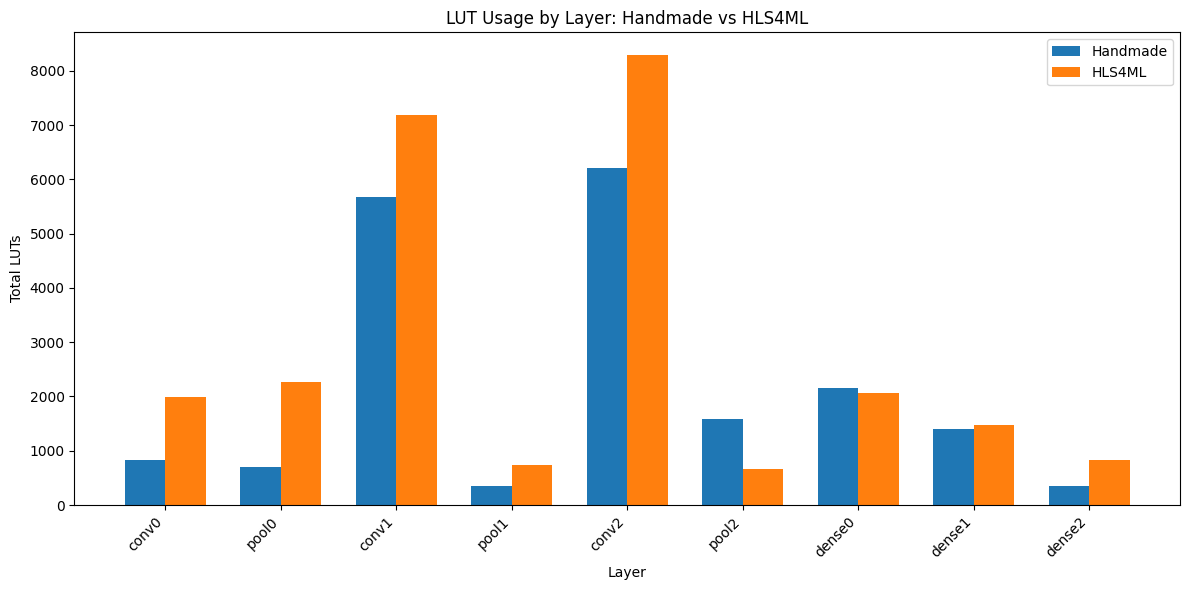

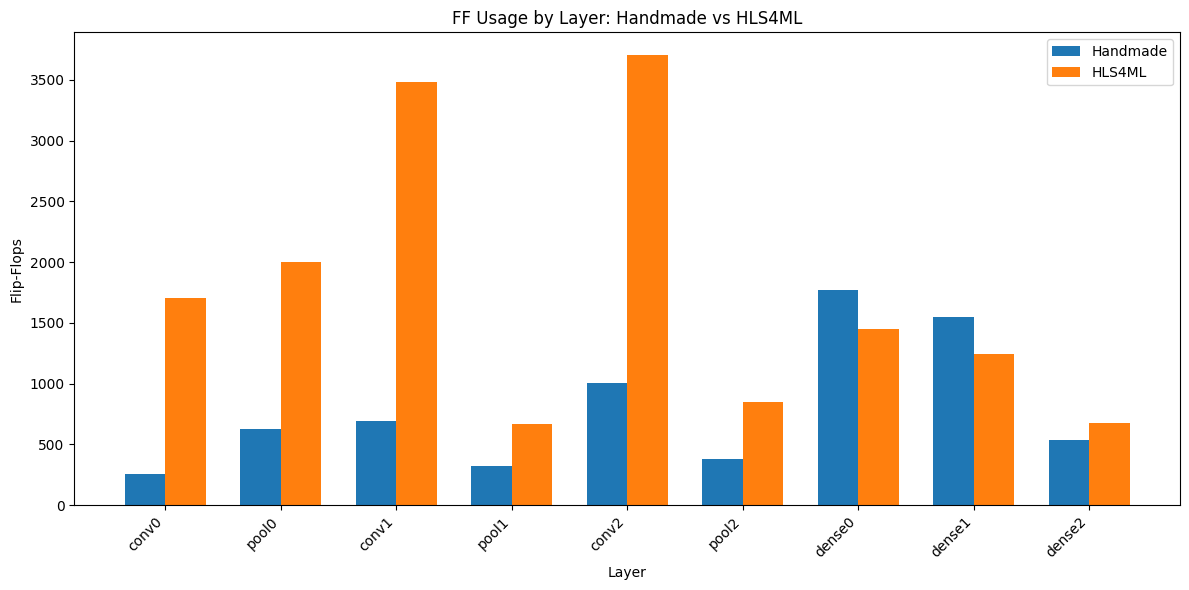

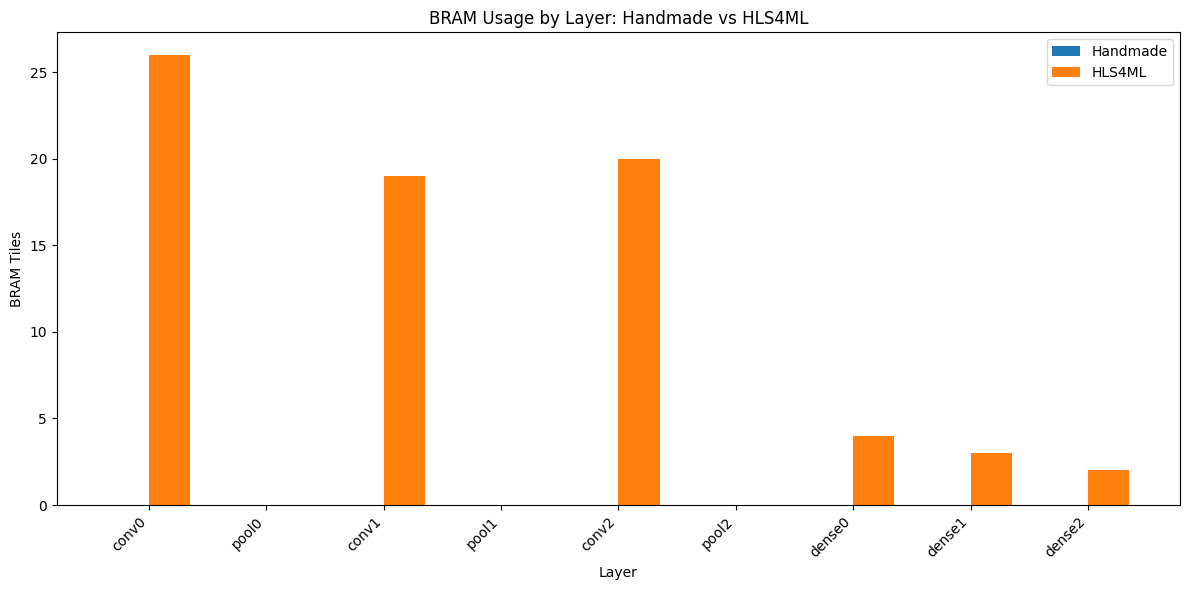

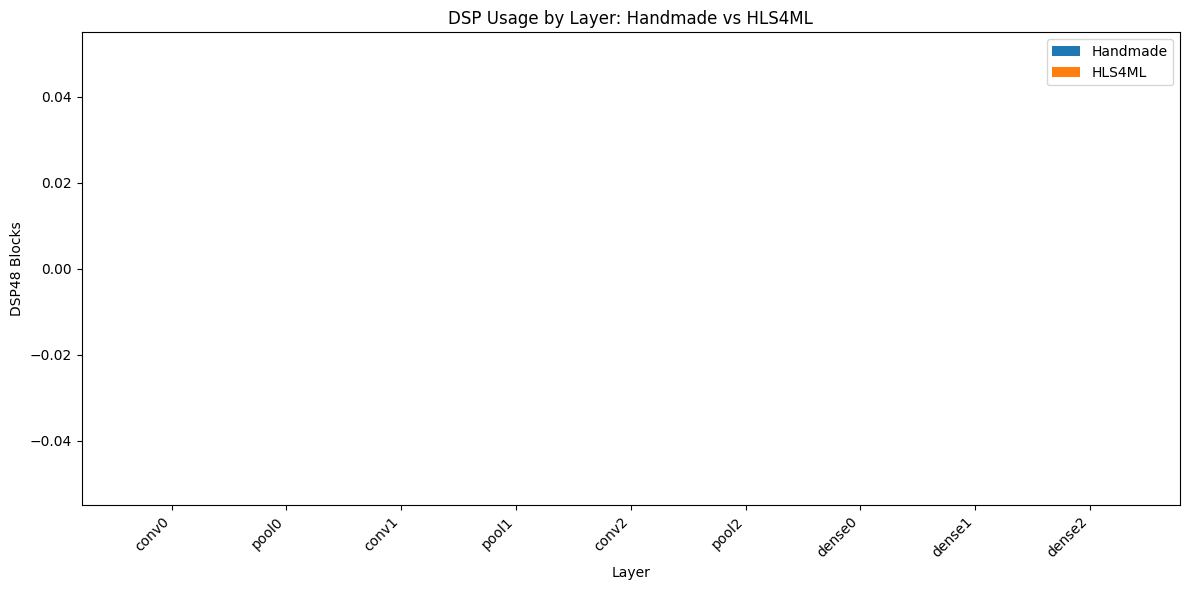

In [7]:
# handmade (11 groups) and hls4ml (20 groups) use different granularity --
# hls4ml keeps ReLU and 'linear' (a batchnorm-rescale identity op) as separate
# instances, while handmade's conv/dense modules have ReLU fused directly inside
# them (see: 'conv2d_output_with_relu_...'). To compare fairly, fold both designs
# down to the same 9 shared logical stages, so each bar represents the same
# underlying computation on both sides regardless of instance-boundary differences.
shared_stages = ['conv0', 'pool0', 'conv1', 'pool1', 'conv2', 'pool2', 'dense0', 'dense1', 'dense2']

hls4ml_fold_map = {
    'conv0': ['conv0', 'linear0', 'relu0'], 'pool0': ['pool0'],
    'conv1': ['conv1', 'linear1', 'relu1'], 'pool1': ['pool1'],
    'conv2': ['conv2', 'linear2', 'relu2'], 'pool2': ['pool2'],
    'dense0': ['dense0', 'linear3', 'relu3'],
    'dense1': ['dense1', 'linear4', 'relu4'],
    'dense2': ['dense2', 'linear5'],
}
handmade_fold_map = {
    'conv0': ['conv0'], 'pool0': ['pool0'],
    'conv1': ['conv1'], 'pool1': ['pool1'],
    'conv2': ['conv2'], 'pool2': ['pool2'],
    'dense0': ['dense0', 'relu0'],  # handmade's relu0 follows dense0
    'dense1': ['dense1', 'relu1'],  # handmade's relu1 follows dense1
    'dense2': ['dense2'],           # no activation after the final dense layer
}

def fold(data, fold_map):
    """Sums each design's sub-instances into the shared 9-stage grouping."""
    out = {}
    for stage, parts in fold_map.items():
        out[stage] = {m: sum(data[p][m] for p in parts) for m in ['total_luts','ffs','bram','dsp48']}
    return out

handmade_shared = fold(handmade_data, handmade_fold_map)
hls4ml_shared = fold(hls4ml_data, hls4ml_fold_map)


def plot_comparison(handmade, hls4ml, metric, ylabel, title):
    """
    Grouped bar chart, two bars per layer (handmade vs. hls4ml), showing
    absolute resource usage (not % share) side by side for one resource type.
    """
    stages = shared_stages
    x = np.arange(len(stages))
    width = 0.35

    handmade_vals = [handmade[s][metric] for s in stages]
    hls4ml_vals = [hls4ml[s][metric] for s in stages]

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, handmade_vals, width, label='Handmade')
    plt.bar(x + width/2, hls4ml_vals, width, label='HLS4ML')
    plt.xticks(x, stages, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.xlabel('Layer')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# One chart per resource type
plot_comparison(handmade_shared, hls4ml_shared, 'total_luts', 'Total LUTs', 'LUT Usage by Layer: Handmade vs HLS4ML')
plot_comparison(handmade_shared, hls4ml_shared, 'ffs', 'Flip-Flops', 'FF Usage by Layer: Handmade vs HLS4ML')
plot_comparison(handmade_shared, hls4ml_shared, 'bram', 'BRAM Tiles', 'BRAM Usage by Layer: Handmade vs HLS4ML')
plot_comparison(handmade_shared, hls4ml_shared, 'dsp48', 'DSP48 Blocks', 'DSP Usage by Layer: Handmade vs HLS4ML')